# 02i — LSOA Stories & Archetype Deep Dives

**Purpose:** Build intuition by examining individual LSOAs in depth.
Statistics tell you averages. Stories tell you what it's actually like
to live in a specific place with a specific bus service.

**Sections:**
1. Name each cluster archetype with policy-meaningful labels
2. Single-LSOA deep dives: 10 representative LSOAs traced across ALL datasets
3. "Worst 50" transport deserts — fully profiled
4. Case studies: a day in the life of a bus user in each archetype
5. Cluster comparison on every dimension
6. LSOAs that defy expectations (anomalies worth investigating)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

RAW = Path('/Users/souravamseekarmarti/Projects/aequitas/data/raw')
AUDIT = Path('/Users/souravamseekarmarti/Projects/aequitas/data/audit')

In [2]:
# Load all data for comprehensive profiling
features = pd.read_parquet(AUDIT / 'lsoa_feature_matrix_clustered.parquet')

# Load service levels if available
service_path = AUDIT / 'lsoa_service_levels.parquet'
if service_path.exists():
    service = pd.read_parquet(service_path)
    features = features.merge(service.drop(columns=[c for c in service.columns if c in features.columns and c != 'lsoa_cd'],
                                            errors='ignore'),
                               on='lsoa_cd', how='left')

# Load accessibility if available
access_path = AUDIT / 'lsoa_accessibility.parquet'
if access_path.exists():
    access = pd.read_parquet(access_path)
    code_col = [c for c in access.columns if 'cd' in c.lower() or 'code' in c.lower()][0]
    access = access.rename(columns={code_col: 'lsoa_cd'})
    access_cols = [c for c in access.columns if c not in features.columns or c == 'lsoa_cd']
    features = features.merge(access[access_cols], on='lsoa_cd', how='left')

# Load IMD for LSOA names
imd = pd.read_csv(RAW / 'imd' / 'imd2025_all_ranks_scores_deciles.csv',
                    usecols=lambda c: 'LSOA' in c or 'Local Authority' in c)
imd_code = [c for c in imd.columns if 'code' in c.lower() and 'LSOA' in c][0]
imd_name = [c for c in imd.columns if 'name' in c.lower() and 'LSOA' in c][0]
la_name_cols = [c for c in imd.columns if 'Local Authority' in c and 'name' in c.lower()]
la_name = la_name_cols[0] if la_name_cols else None

features = features.merge(imd.rename(columns={imd_code: 'lsoa_cd', imd_name: 'lsoa_name'}),
                            on='lsoa_cd', how='left')
if la_name:
    features = features.rename(columns={la_name: 'la_name'})

print(f"Full feature set: {len(features):,} LSOAs × {len(features.columns)} columns")
print(f"Columns: {list(features.columns)}")
print(f"Clusters: {sorted(features['cluster'].unique())}")

Full feature set: 33,755 LSOAs × 59 columns
Columns: ['lsoa_cd', 'imd_score', 'imd_decile', 'income_score', 'employment_score', 'education_score', 'health_score', 'crime_score', 'barriers_score', 'living_env_score', 'geo_barriers_score', 'idaci_score', 'idaopi_score', 'population', 'elderly_pct', 'nocar_pct', 'nonwhite_pct', 'unemployment_pct', 'ruc_class', 'stop_count', 'stops_per_1k', 'cluster', 'n_deprived', 'total_weekday_trips', 'total_saturday_trips', 'total_sunday_trips', 'weekday_trips_per_1k', 'n_stops', 'mean_weekday_trips', 'stops_with_evening', 'median_service_span', 'stops_with_no_service', 'stops_minimal_service', 'dist_nearest_stop_m', 'dist_5th_stop_m', 'nearest_weekday_trips', 'nearest_has_evening', 'dist_score', 'freq_score', 'time_score', 'access_score', 'lsoa_name', 'Local Authority District code (2024)', 'la_name', 'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)', 'Income Decile (where 1 is most deprived 10% of LSOAs)', 'Employme

## 1. Name the Cluster Archetypes

Each cluster should get a meaningful name based on what defines it.

In [3]:
# Profile each cluster across all numeric dimensions
profile_cols = [c for c in features.select_dtypes(include=[np.number]).columns
                if c not in ['imd_decile', 'cluster', 'n_deprived']]

cluster_means = features.groupby('cluster')[profile_cols].mean()
overall_means = features[profile_cols].mean()
overall_stds = features[profile_cols].std()

# Normalized deviation from mean
norm_profiles = (cluster_means - overall_means) / overall_stds

print("=== Cluster Profiles (standardized deviation from national mean) ===")
print(norm_profiles.round(2).to_string())

=== Cluster Profiles (standardized deviation from national mean) ===
         imd_score  income_score  employment_score  education_score  health_score  crime_score  barriers_score  living_env_score  geo_barriers_score  idaci_score  idaopi_score  population  elderly_pct  nocar_pct  nonwhite_pct  unemployment_pct  stop_count  stops_per_1k  total_weekday_trips  total_saturday_trips  total_sunday_trips  weekday_trips_per_1k  n_stops  mean_weekday_trips  stops_with_evening  median_service_span  stops_with_no_service  stops_minimal_service  dist_nearest_stop_m  dist_5th_stop_m  nearest_weekday_trips  dist_score  freq_score  time_score  access_score  Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)  Income Decile (where 1 is most deprived 10% of LSOAs)  Employment Decile (where 1 is most deprived 10% of LSOAs)  Education, Skills and Training Decile (where 1 is most deprived 10% of LSOAs)  Health Deprivation and Disability Decile (where 1 is most deprived 10% 

In [4]:
# Auto-generate archetype names based on dominant characteristics
archetype_names = {}
for cluster_id in sorted(features['cluster'].unique()):
    profile = norm_profiles.loc[cluster_id]
    n = (features['cluster'] == cluster_id).sum()

    # Top 3 high and low characteristics
    high = profile.nlargest(3)
    low = profile.nsmallest(3)

    # RUC distribution
    ruc_dist = features[features['cluster'] == cluster_id]['ruc_class'].value_counts(normalize=True)
    top_ruc = ruc_dist.index[0] if len(ruc_dist) > 0 else 'Unknown'
    is_urban = str(top_ruc).startswith('U')

    # Determine name
    traits = []
    if profile.get('imd_score', 0) > 0.5:
        traits.append('Deprived')
    elif profile.get('imd_score', 0) < -0.5:
        traits.append('Affluent')

    if profile.get('elderly_pct', 0) > 0.5:
        traits.append('Elderly')
    elif profile.get('elderly_pct', 0) < -0.5:
        traits.append('Young')

    if profile.get('nonwhite_pct', 0) > 0.5:
        traits.append('Diverse')

    if profile.get('nocar_pct', 0) > 0.5:
        traits.append('Car-Free')

    if is_urban:
        traits.append('Urban')
    else:
        traits.append('Rural')

    name = ' '.join(traits) if traits else f'Cluster {cluster_id}'
    archetype_names[cluster_id] = name

    print(f"\n=== Cluster {cluster_id}: \"{name}\" (n={n:,}) ===")
    print(f"  Top RUC: {top_ruc} ({100*ruc_dist.iloc[0]:.0f}%)")
    print(f"  HIGHEST: {', '.join([f'{k} (+{v:.1f}σ)' for k, v in high.items()])}")
    print(f"  LOWEST:  {', '.join([f'{k} ({v:.1f}σ)' for k, v in low.items()])}")

features['archetype'] = features['cluster'].map(archetype_names)


=== Cluster 0: "Affluent Urban" (n=16,944) ===
  Top RUC: UN1 (83%)
  HIGHEST: Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs) (+0.6σ), Income Deprivation Affecting Children Index (IDACI) Decile (where 1 is most deprived 10% of LSOAs) (+0.5σ), Income Deprivation Affecting Older People (IDAOPI) Decile (where 1 is most deprived 10% of LSOAs) (+0.5σ)
  LOWEST:  imd_score (-0.6σ), idaci_score (-0.6σ), income_score (-0.6σ)

=== Cluster 1: "Deprived Young Diverse Car-Free Urban" (n=6,023) ===
  Top RUC: UN1 (100%)
  HIGHEST: nonwhite_pct (+1.7σ), nocar_pct (+1.3σ), unemployment_pct (+1.3σ)
  LOWEST:  Wider Barriers Sub-domain Decile (where 1 is most deprived 10% of LSOAs) (-1.3σ), geo_barriers_score (-1.1σ), Outdoors Sub-domain Decile (where 1 is most deprived 10% of LSOAs) (-1.1σ)

=== Cluster 2: "Elderly Rural" (n=4,588) ===
  Top RUC: RSN1 (35%)
  HIGHEST: geo_barriers_score (+1.8σ), barriers_score (+1.3σ), dist_score (+1.3σ)
  LOWEST:  Geographical Bar

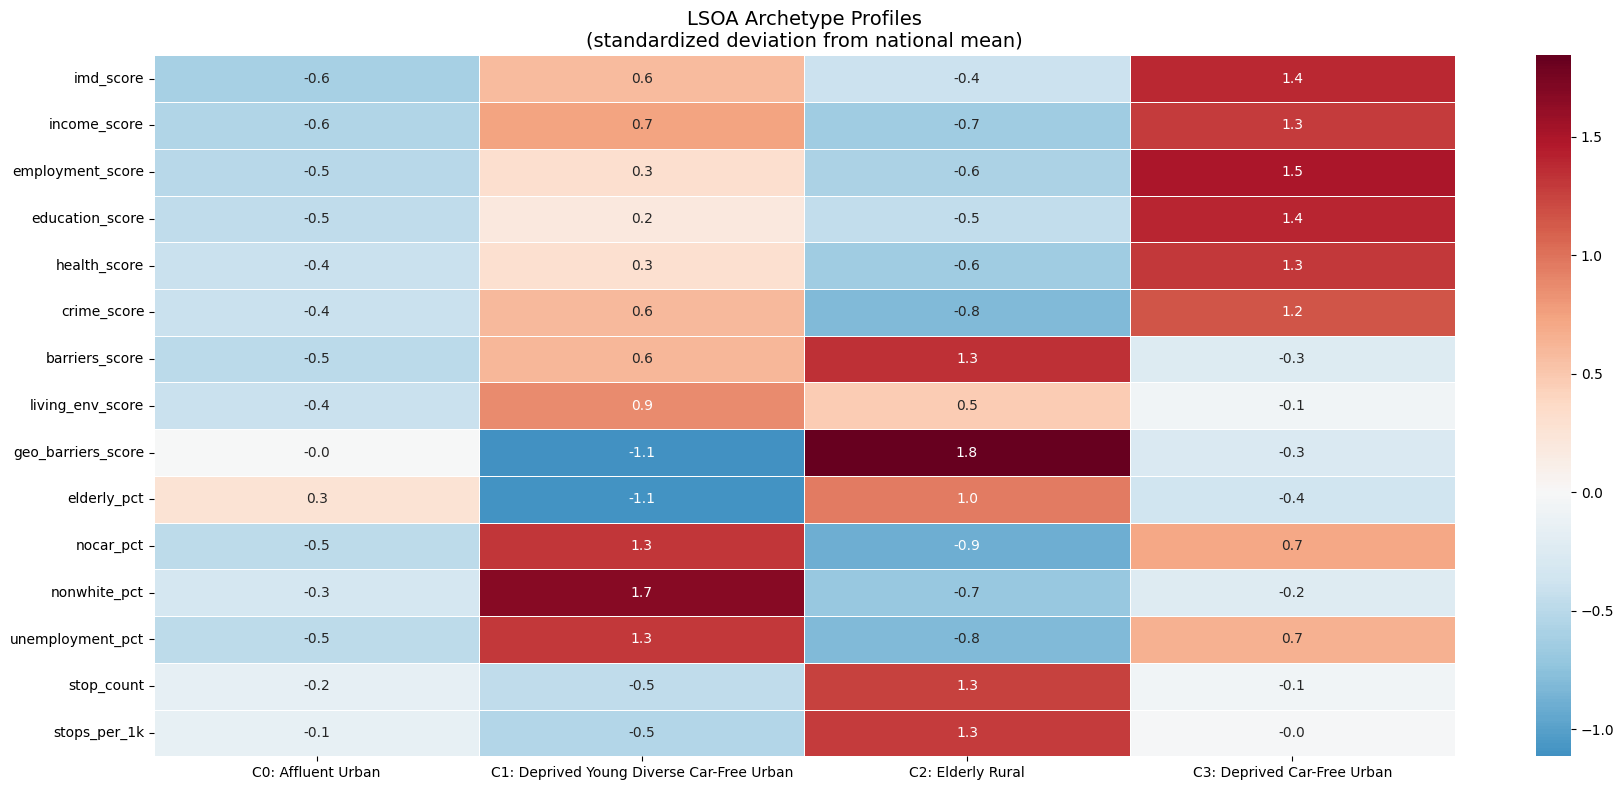

In [5]:
# Visual: normalized heatmap with archetype names
fig, ax = plt.subplots(figsize=(18, 8))
display_cols = [c for c in ['imd_score', 'income_score', 'employment_score', 'education_score',
                             'health_score', 'crime_score', 'barriers_score', 'living_env_score',
                             'geo_barriers_score', 'elderly_pct', 'nocar_pct', 'nonwhite_pct',
                             'unemployment_pct', 'stop_count', 'stops_per_1k']
                if c in norm_profiles.columns]

display_profiles = norm_profiles[display_cols].copy()
display_profiles.index = [f"C{i}: {archetype_names.get(i, '')}" for i in display_profiles.index]

sns.heatmap(display_profiles.T, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5)
ax.set_title('LSOA Archetype Profiles\n(standardized deviation from national mean)', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Single-LSOA Deep Dives

Pick representative LSOAs and trace EVERY data point.

In [6]:
def profile_lsoa(lsoa_code, df):
    """Generate a comprehensive profile for a single LSOA."""
    row = df[df['lsoa_cd'] == lsoa_code]
    if len(row) == 0:
        print(f"LSOA {lsoa_code} not found")
        return

    row = row.iloc[0]
    print(f"\n{'='*80}")
    print(f"  LSOA: {row.get('lsoa_name', lsoa_code)} ({lsoa_code})")
    print(f"  Local Authority: {row.get('la_name', 'Unknown')}")
    print(f"{'='*80}")

    print(f"\n  DEMOGRAPHICS")
    print(f"    Population: {row.get('population', 'N/A'):,.0f}")
    print(f"    Elderly (65+): {row.get('elderly_pct', 'N/A'):.1f}%")
    print(f"    Non-white: {row.get('nonwhite_pct', 'N/A'):.1f}%")
    print(f"    No-car households: {row.get('nocar_pct', 'N/A'):.1f}%")
    print(f"    Unemployment: {row.get('unemployment_pct', 'N/A'):.1f}%")

    print(f"\n  DEPRIVATION")
    print(f"    IMD Score: {row.get('imd_score', 'N/A'):.1f} (Decile {row.get('imd_decile', 'N/A'):.0f})")
    for domain in ['income', 'employment', 'education', 'health', 'crime', 'barriers', 'living_env']:
        col = f'{domain}_score'
        if col in row.index:
            print(f"    {domain.title()}: {row[col]:.3f}")
    if 'geo_barriers_score' in row.index:
        print(f"    Geographical Barriers: {row['geo_barriers_score']:.3f}")
    if 'idaci_score' in row.index:
        print(f"    IDACI (children): {row['idaci_score']:.3f}")
    if 'idaopi_score' in row.index:
        print(f"    IDAOPI (older people): {row['idaopi_score']:.3f}")

    print(f"\n  BUS COVERAGE")
    print(f"    Stops: {row.get('stop_count', 'N/A'):.0f}")
    print(f"    Stops per 1K: {row.get('stops_per_1k', 'N/A'):.1f}")
    if 'total_weekday_trips' in row.index:
        print(f"    Weekday trips: {row.get('total_weekday_trips', 0):.0f}")
        print(f"    Saturday trips: {row.get('total_saturday_trips', 0):.0f}")
        print(f"    Sunday trips: {row.get('total_sunday_trips', 0):.0f}")
    if 'dist_nearest_stop_m' in row.index:
        print(f"    Distance to nearest stop: {row['dist_nearest_stop_m']:.0f}m")
    if 'access_score' in row.index:
        print(f"    Accessibility score: {row['access_score']:.1f}/100 (0=best)")

    print(f"\n  CLASSIFICATION")
    print(f"    Urban/Rural: {row.get('ruc_class', 'N/A')}")
    print(f"    Cluster: {row.get('cluster', 'N/A')} ({row.get('archetype', 'N/A')})")
    print(f"    Deprivation dimensions: {row.get('n_deprived', 'N/A'):.0f}")

In [7]:
# Select 10 representative LSOAs across all clusters
print("=== 10 REPRESENTATIVE LSOA DEEP DIVES ===\n")
print("Selection criteria: median LSOA within each cluster, plus extreme cases")

representatives = []

# One from each cluster (closest to cluster centroid in IMD score)
for cluster_id in sorted(features['cluster'].unique()):
    cluster_data = features[features['cluster'] == cluster_id]
    median_imd = cluster_data['imd_score'].median()
    closest = (cluster_data['imd_score'] - median_imd).abs().idxmin()
    representatives.append(features.loc[closest, 'lsoa_cd'])

# Add extreme cases
# Most deprived with good bus coverage
most_dep_good_bus = features[(features['imd_decile'] == 1) & (features['stops_per_1k'] > features['stops_per_1k'].quantile(0.8))]
if len(most_dep_good_bus) > 0:
    representatives.append(most_dep_good_bus.iloc[0]['lsoa_cd'])

# Most deprived with NO bus stops
most_dep_no_bus = features[(features['imd_decile'] == 1) & (features['stop_count'] == 0)]
if len(most_dep_no_bus) > 0:
    representatives.append(most_dep_no_bus.iloc[0]['lsoa_cd'])

# Affluent rural with no bus
affluent_rural_no_bus = features[(features['imd_decile'] >= 8) &
                                  (features['ruc_class'].str.startswith('R', na=False)) &
                                  (features['stop_count'] <= 1)]
if len(affluent_rural_no_bus) > 0:
    representatives.append(affluent_rural_no_bus.iloc[0]['lsoa_cd'])

# Highest elderly % with few stops
elderly_few_stops = features[(features['elderly_pct'] > features['elderly_pct'].quantile(0.95)) &
                               (features['stops_per_1k'] < features['stops_per_1k'].quantile(0.2))]
if len(elderly_few_stops) > 0:
    representatives.append(elderly_few_stops.iloc[0]['lsoa_cd'])

# Profile each
for lsoa_cd in representatives[:10]:
    profile_lsoa(lsoa_cd, features)

=== 10 REPRESENTATIVE LSOA DEEP DIVES ===

Selection criteria: median LSOA within each cluster, plus extreme cases



  LSOA: North Tyneside 029C (E01008574)
  Local Authority: North Tyneside

  DEMOGRAPHICS
    Population: 1,933
    Elderly (65+): 19.4%
    Non-white: 3.7%
    No-car households: 20.5%
    Unemployment: 2.9%

  DEPRIVATION
    IMD Score: 10.9 (Decile 8)
    Income: 0.146
    Employment: 0.091
    Education: 8.574
    Health: 0.039
    Crime: 0.139
    Barriers: 4.939
    Living_Env: 10.238
    Geographical Barriers: 25.811
    IDACI (children): 0.137
    IDAOPI (older people): 0.194

  BUS COVERAGE
    Stops: 6
    Stops per 1K: 3.1
    Weekday trips: 0
    Saturday trips: nan
    Sunday trips: nan
    Distance to nearest stop: 262m
    Accessibility score: 21.2/100 (0=best)

  CLASSIFICATION
    Urban/Rural: UN1
    Cluster: 0 (Affluent Urban)
    Deprivation dimensions: 0

  LSOA: Brighton and Hove 008E (E01016909)
  Local Authority: Brighton and Hove

  DEMOGRAPHICS
    Population: 1,734
    Elderly (65+): 9.3%
    Non-white: 20.3%
    No-car households: 40.3%
    Unemployment: 8.

## 3. Worst 50 Transport Deserts

Composite ranking: high deprivation + low bus coverage + high elderly +
high no-car + large distance to stop.

In [8]:
# Compute transport desert score
desert_score_cols = ['imd_score', 'nocar_pct', 'elderly_pct']
available_desert_cols = [c for c in desert_score_cols if c in features.columns]

# Normalize each to 0-1
for c in available_desert_cols:
    features[f'{c}_norm'] = (features[c] - features[c].min()) / (features[c].max() - features[c].min())

# Inverse of coverage (higher = worse)
if 'stops_per_1k' in features.columns:
    max_spk = features['stops_per_1k'].quantile(0.95)
    features['coverage_deficit_norm'] = 1 - (features['stops_per_1k'].clip(upper=max_spk) / max_spk)
else:
    features['coverage_deficit_norm'] = 0

if 'dist_nearest_stop_m' in features.columns:
    max_dist = features['dist_nearest_stop_m'].quantile(0.95)
    features['distance_norm'] = features['dist_nearest_stop_m'].clip(upper=max_dist) / max_dist
else:
    features['distance_norm'] = 0

# Composite score
norm_cols = [f'{c}_norm' for c in available_desert_cols] + ['coverage_deficit_norm', 'distance_norm']
norm_cols = [c for c in norm_cols if c in features.columns]
features['desert_score'] = features[norm_cols].mean(axis=1)

# Top 50 deserts
deserts = features.nlargest(50, 'desert_score')
print("=== TOP 50 TRANSPORT DESERTS ===")
print("(Ranked by composite score: deprivation + no-car + elderly + low coverage + distance)\n")

display_cols_desert = ['lsoa_cd', 'lsoa_name', 'imd_decile', 'imd_score', 'elderly_pct',
                        'nocar_pct', 'stop_count', 'stops_per_1k', 'ruc_class', 'desert_score']
display_cols_desert = [c for c in display_cols_desert if c in deserts.columns]
print(deserts[display_cols_desert].to_string(index=False))

=== TOP 50 TRANSPORT DESERTS ===
(Ranked by composite score: deprivation + no-car + elderly + low coverage + distance)

  lsoa_cd                         lsoa_name  imd_decile  imd_score  elderly_pct  nocar_pct  stop_count  stops_per_1k ruc_class  desert_score
E01021495                 Castle Point 009C           4     23.740    58.078818  24.787776           0      0.000000       UN1      0.668112
E01017281                  Southampton 032D           1     75.537     7.347204  50.144928           1      0.650618       UN1      0.647206
E01018078                      Fenland 007B           1     48.324    26.014866  28.966346           0      0.000000       UF1      0.645560
E01011792                    Wakefield 039D           1     72.504    15.977961  39.741519           3      2.054795      RLN1      0.643271
E01026467                    Breckland 015C           1     53.265     7.985644  37.285903           0      0.000000       UF1      0.619612
E01019269                     Cope

In [9]:
# Profile top 5 deserts in detail
print("\n=== DETAILED PROFILES: TOP 5 TRANSPORT DESERTS ===")
for _, row in deserts.head(5).iterrows():
    profile_lsoa(row['lsoa_cd'], features)


=== DETAILED PROFILES: TOP 5 TRANSPORT DESERTS ===



  LSOA: Castle Point 009C (E01021495)
  Local Authority: Castle Point

  DEMOGRAPHICS
    Population: 2,030
    Elderly (65+): 58.1%
    Non-white: 1.8%
    No-car households: 24.8%
    Unemployment: 1.7%

  DEPRIVATION
    IMD Score: 23.7 (Decile 4)
    Income: 0.193
    Employment: 0.141
    Education: 33.767
    Health: 0.186
    Crime: -0.968
    Barriers: 29.100
    Living_Env: 41.487
    Geographical Barriers: 48.245
    IDACI (children): 0.260
    IDAOPI (older people): 0.213

  BUS COVERAGE
    Stops: 0
    Stops per 1K: 0.0
    Weekday trips: 0
    Saturday trips: nan
    Sunday trips: nan
    Distance to nearest stop: 882m
    Accessibility score: -22.4/100 (0=best)

  CLASSIFICATION
    Urban/Rural: UN1
    Cluster: 2 (Elderly Rural)
    Deprivation dimensions: 5

  LSOA: Southampton 032D (E01017281)
  Local Authority: Southampton

  DEMOGRAPHICS
    Population: 1,537
    Elderly (65+): 7.3%
    Non-white: 10.1%
    No-car households: 50.1%
    Unemployment: 8.0%

  DEPRIVA

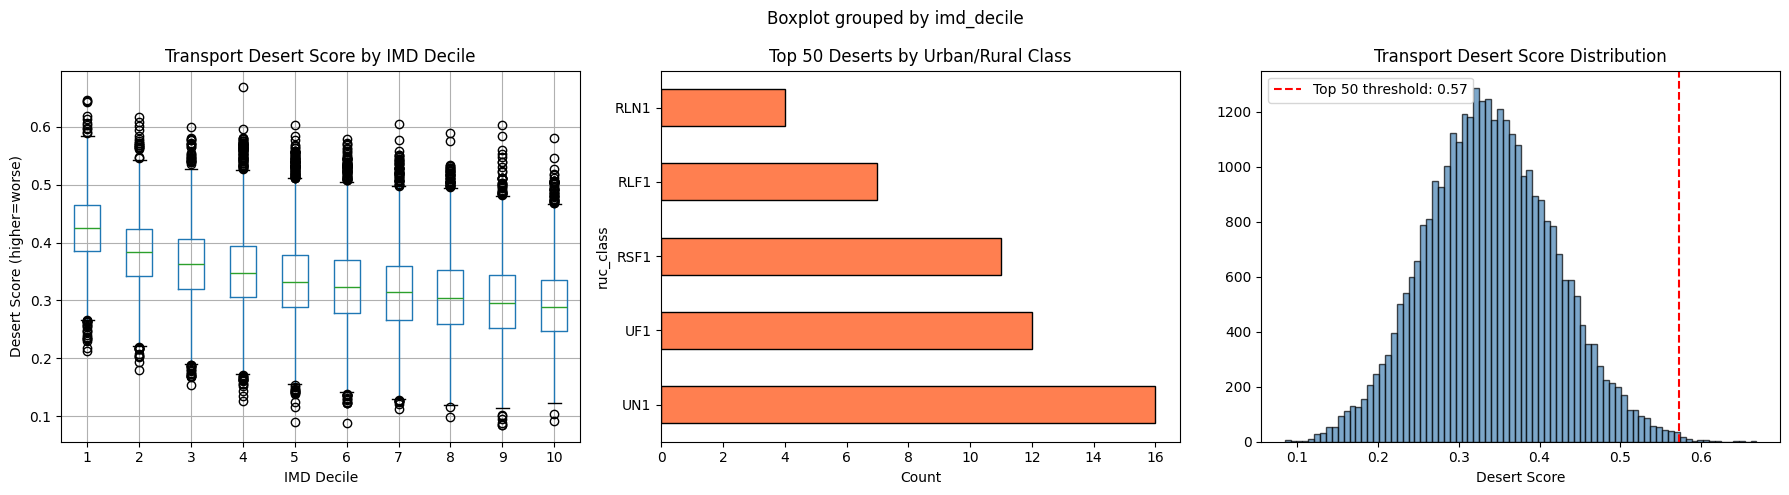

In [10]:
# Desert distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Desert score by IMD decile
features.boxplot(column='desert_score', by='imd_decile', ax=axes[0])
axes[0].set_title('Transport Desert Score by IMD Decile')
axes[0].set_xlabel('IMD Decile')
axes[0].set_ylabel('Desert Score (higher=worse)')

# Where are the deserts? By RUC
desert_ruc = deserts['ruc_class'].value_counts()
desert_ruc.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_title('Top 50 Deserts by Urban/Rural Class')
axes[1].set_xlabel('Count')

# Desert score histogram
axes[2].hist(features['desert_score'], bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[2].axvline(deserts['desert_score'].min(), color='red', linestyle='--',
                label=f'Top 50 threshold: {deserts["desert_score"].min():.2f}')
axes[2].set_title('Transport Desert Score Distribution')
axes[2].set_xlabel('Desert Score')
axes[2].legend()
plt.tight_layout()
plt.show()

## 4. Cluster Comparison — Every Dimension

In [11]:
# Comprehensive cluster comparison
compare_cols = [c for c in ['imd_score', 'income_score', 'employment_score', 'education_score',
                             'health_score', 'crime_score', 'barriers_score', 'living_env_score',
                             'geo_barriers_score', 'idaci_score', 'idaopi_score',
                             'population', 'elderly_pct', 'nocar_pct', 'nonwhite_pct',
                             'unemployment_pct', 'stop_count', 'stops_per_1k', 'desert_score']
                if c in features.columns]

# Add service metrics if available
for c in ['total_weekday_trips', 'total_saturday_trips', 'total_sunday_trips',
           'weekday_trips_per_1k', 'dist_nearest_stop_m']:
    if c in features.columns:
        compare_cols.append(c)

cluster_comparison = features.groupby('archetype')[compare_cols].agg(['mean', 'median']).round(2)

print("=== Full Cluster Comparison ===")
# Print means only for readability
cluster_means_display = features.groupby('archetype')[compare_cols].mean().round(2)
print(cluster_means_display.to_string())

=== Full Cluster Comparison ===
                                       imd_score  income_score  employment_score  education_score  health_score  crime_score  barriers_score  living_env_score  geo_barriers_score  idaci_score  idaopi_score  population  elderly_pct  nocar_pct  nonwhite_pct  unemployment_pct  stop_count  stops_per_1k  desert_score  total_weekday_trips  total_saturday_trips  total_sunday_trips  weekday_trips_per_1k  dist_nearest_stop_m
archetype                                                                                                                                                                                                                                                                                                                                                                                                                          
Affluent Urban                             12.14          0.14              0.09            13.37         -0.36        -0.35    

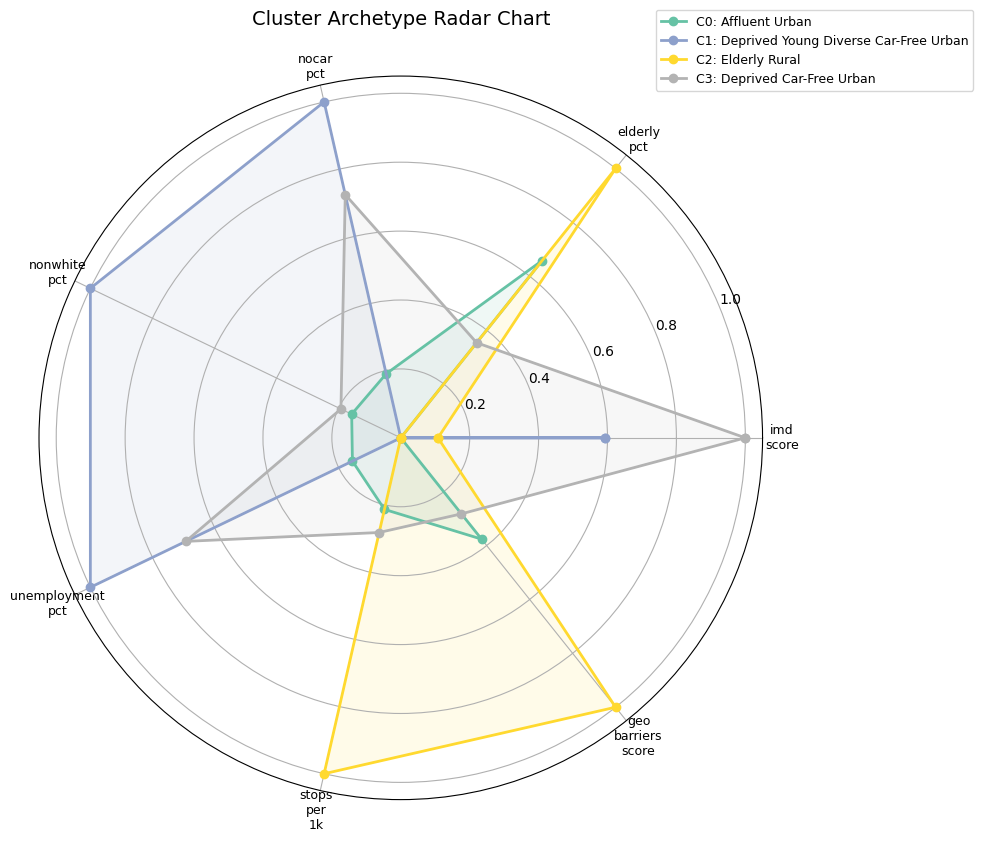

In [12]:
# Radar chart for each cluster
from matplotlib.patches import FancyBboxPatch

radar_cols = [c for c in ['imd_score', 'elderly_pct', 'nocar_pct', 'nonwhite_pct',
                            'unemployment_pct', 'stops_per_1k', 'geo_barriers_score']
              if c in features.columns]

if len(radar_cols) >= 4:
    # Normalize to 0-1 for radar
    radar_data = features.groupby('cluster')[radar_cols].mean()
    radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

    n_clusters = len(radar_norm)
    n_vars = len(radar_cols)
    angles = np.linspace(0, 2 * np.pi, n_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
    colors = plt.cm.Set2(np.linspace(0, 1, n_clusters))

    for i, (cluster_id, row) in enumerate(radar_norm.iterrows()):
        values = row.values.tolist()
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f'C{cluster_id}: {archetype_names.get(cluster_id, "")}',
                color=colors[i])
        ax.fill(angles, values, alpha=0.1, color=colors[i])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([c.replace('_', '\n') for c in radar_cols], fontsize=9)
    ax.set_title('Cluster Archetype Radar Chart', fontsize=14, pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)
    plt.tight_layout()
    plt.show()

## 5. LSOAs That Defy Expectations (Anomalies)

LSOAs where the relationship between deprivation and bus coverage
breaks the expected pattern.

In [13]:
print("=== ANOMALIES: LSOAs That Defy Expectations ===\n")

# Type 1: Very deprived (decile 1) but excellent bus coverage
anomaly_1 = features[(features['imd_decile'] == 1) &
                       (features['stops_per_1k'] > features['stops_per_1k'].quantile(0.9))]
print(f"1. Most deprived + excellent coverage: {len(anomaly_1):,} LSOAs")
if len(anomaly_1) > 0:
    print(f"   Mean stops/1K: {anomaly_1['stops_per_1k'].mean():.1f}")
    print(f"   These are urban deprived areas near transit hubs")
    print(f"   Example: {anomaly_1.iloc[0].get('lsoa_name', anomaly_1.iloc[0]['lsoa_cd'])}")

# Type 2: Affluent (decile 9-10) but zero bus stops
anomaly_2 = features[(features['imd_decile'] >= 9) & (features['stop_count'] == 0)]
print(f"\n2. Affluent + zero stops: {len(anomaly_2):,} LSOAs")
if len(anomaly_2) > 0:
    print(f"   These are wealthy rural areas — everyone drives")
    if 'ruc_class' in anomaly_2.columns:
        print(f"   RUC: {anomaly_2['ruc_class'].value_counts().head(3).to_string()}")

# Type 3: High elderly + high no-car + few stops (triple vulnerability)
anomaly_3 = features[(features['elderly_pct'] > features['elderly_pct'].quantile(0.8)) &
                       (features['nocar_pct'] > features['nocar_pct'].quantile(0.8)) &
                       (features['stops_per_1k'] < features['stops_per_1k'].quantile(0.2))]
print(f"\n3. Elderly + car-free + few stops (triple vulnerable): {len(anomaly_3):,} LSOAs")
if len(anomaly_3) > 0:
    print(f"   Mean elderly: {anomaly_3['elderly_pct'].mean():.1f}%")
    print(f"   Mean no-car: {anomaly_3['nocar_pct'].mean():.1f}%")
    print(f"   Mean stops/1K: {anomaly_3['stops_per_1k'].mean():.1f}")
    print(f"   These are CRITICAL PRIORITY for bus policy intervention")

# Type 4: High diversity + deprived + low coverage
anomaly_4 = features[(features['nonwhite_pct'] > features['nonwhite_pct'].quantile(0.8)) &
                       (features['imd_decile'] <= 3) &
                       (features['stops_per_1k'] < features['stops_per_1k'].median())]
print(f"\n4. Diverse + deprived + below-median coverage: {len(anomaly_4):,} LSOAs")

# Type 5: Rural + deprived (worst of both worlds)
rural_deprived = features[(features['ruc_class'].str.startswith('R', na=False)) &
                            (features['imd_decile'] <= 3)]
print(f"\n5. Rural + most deprived: {len(rural_deprived):,} LSOAs")
if len(rural_deprived) > 0:
    print(f"   Mean stops/1K: {rural_deprived['stops_per_1k'].mean():.1f}")
    print(f"   Mean stop count: {rural_deprived['stop_count'].mean():.1f}")
    print(f"   These face the double penalty: deprived AND physically isolated")

=== ANOMALIES: LSOAs That Defy Expectations ===

1. Most deprived + excellent coverage: 209 LSOAs
   Mean stops/1K: 14.8
   These are urban deprived areas near transit hubs
   Example: Bolton 016D

2. Affluent + zero stops: 688 LSOAs
   These are wealthy rural areas — everyone drives
   RUC: ruc_class
UN1     549
RLN1     59
UF1      44

3. Elderly + car-free + few stops (triple vulnerable): 9 LSOAs
   Mean elderly: 31.1%
   Mean no-car: 40.3%
   Mean stops/1K: 0.1
   These are CRITICAL PRIORITY for bus policy intervention

4. Diverse + deprived + below-median coverage: 2,904 LSOAs

5. Rural + most deprived: 500 LSOAs
   Mean stops/1K: 8.0
   Mean stop count: 12.9
   These face the double penalty: deprived AND physically isolated


In [14]:
# Deep-dive the triple-vulnerable LSOAs
if len(anomaly_3) > 0:
    print("\n=== TOP 10 TRIPLE-VULNERABLE LSOAs ===")
    print("(Elderly + Car-free + Few Stops)")
    for _, row in anomaly_3.nlargest(10, 'elderly_pct').iterrows():
        profile_lsoa(row['lsoa_cd'], features)


=== TOP 10 TRIPLE-VULNERABLE LSOAs ===
(Elderly + Car-free + Few Stops)

  LSOA: Shropshire 019H (E01035064)
  Local Authority: Shropshire

  DEMOGRAPHICS
    Population: 1,009
    Elderly (65+): 38.6%
    Non-white: 5.7%
    No-car households: 37.5%
    Unemployment: 2.1%

  DEPRIVATION
    IMD Score: 13.5 (Decile 7)
    Income: 0.146
    Employment: 0.100
    Education: 8.303
    Health: 0.201
    Crime: 0.266
    Barriers: 8.098
    Living_Env: 24.338
    Geographical Barriers: 27.115
    IDACI (children): 0.244
    IDAOPI (older people): 0.174

  BUS COVERAGE
    Stops: 0
    Stops per 1K: 0.0
    Weekday trips: 0
    Saturday trips: nan
    Sunday trips: nan
    Distance to nearest stop: 78m
    Accessibility score: -15.2/100 (0=best)

  CLASSIFICATION
    Urban/Rural: UN1
    Cluster: 0 (Affluent Urban)
    Deprivation dimensions: 3

  LSOA: Braintree 017A (E01021415)
  Local Authority: Braintree

  DEMOGRAPHICS
    Population: 1,564
    Elderly (65+): 37.0%
    Non-white: 6.6%


## 6. Day in the Life — Policy Narratives

What does transport access actually MEAN for residents?

In [15]:
print("=" * 80)
print("  DAY IN THE LIFE: BUS ACCESS BY ARCHETYPE")
print("=" * 80)

for cluster_id, name in sorted(archetype_names.items()):
    cluster_data = features[features['cluster'] == cluster_id]
    n = len(cluster_data)
    med = cluster_data.median(numeric_only=True)

    print(f"\n--- {name} (Cluster {cluster_id}, n={n:,}) ---")

    # Population profile
    print(f"  Typical LSOA: {med.get('population', 0):.0f} people, "
          f"{med.get('elderly_pct', 0):.0f}% elderly, "
          f"{med.get('nocar_pct', 0):.0f}% no-car households")

    # Deprivation
    print(f"  Deprivation: IMD score {med.get('imd_score', 0):.1f} "
          f"(decile {med.get('imd_decile', 0):.0f})")

    # Bus access
    stops = med.get('stop_count', 0)
    spk = med.get('stops_per_1k', 0)
    print(f"  Bus stops: {stops:.0f} ({spk:.1f} per 1K)")

    if 'total_weekday_trips' in med.index:
        wk = med.get('total_weekday_trips', 0)
        sat = med.get('total_saturday_trips', 0)
        sun = med.get('total_sunday_trips', 0)
        print(f"  Weekday trips: {wk:.0f}, Saturday: {sat:.0f}, Sunday: {sun:.0f}")

    if 'dist_nearest_stop_m' in med.index:
        dist = med.get('dist_nearest_stop_m', 0)
        print(f"  Walk to nearest stop: {dist:.0f}m ({dist/80:.0f} mins at 80m/min)")

    # Policy narrative
    if med.get('imd_decile', 5) <= 2 and stops < 3:
        print(f"  ⚠ POLICY FLAG: Deprived area with minimal bus infrastructure")
    if med.get('elderly_pct', 0) > 25 and med.get('nocar_pct', 0) > 30 and stops < 5:
        print(f"  ⚠ POLICY FLAG: Elderly car-free population with few stops")
    if med.get('total_sunday_trips', 0) == 0 and stops > 0:
        print(f"  ⚠ POLICY FLAG: Has bus stops but no Sunday service")

  DAY IN THE LIFE: BUS ACCESS BY ARCHETYPE

--- Affluent Urban (Cluster 0, n=16,944) ---
  Typical LSOA: 1570 people, 21% elderly, 14% no-car households
  Deprivation: IMD score 10.9 (decile 8)
  Bus stops: 6 (3.9 per 1K)
  Weekday trips: 0, Saturday: nan, Sunday: nan
  Walk to nearest stop: 177m (2 mins at 80m/min)

--- Deprived Young Diverse Car-Free Urban (Cluster 1, n=6,023) ---
  Typical LSOA: 1792 people, 9% elderly, 43% no-car households
  Deprivation: IMD score 28.3 (decile 3)
  Bus stops: 3 (1.8 per 1K)
  Weekday trips: 0, Saturday: nan, Sunday: nan
  Walk to nearest stop: 138m (2 mins at 80m/min)

--- Elderly Rural (Cluster 2, n=4,588) ---
  Typical LSOA: 1600 people, 27% elderly, 8% no-car households
  Deprivation: IMD score 14.7 (decile 6)
  Bus stops: 16 (10.0 per 1K)
  Weekday trips: 0, Saturday: nan, Sunday: nan
  Walk to nearest stop: 579m (7 mins at 80m/min)

--- Deprived Car-Free Urban (Cluster 3, n=6,200) ---
  Typical LSOA: 1578 people, 15% elderly, 33% no-car house

## Summary

In [16]:
# Save desert rankings
deserts_output = features.nlargest(500, 'desert_score')
desert_cols = [c for c in ['lsoa_cd', 'lsoa_name', 'la_name', 'imd_score', 'imd_decile',
                             'elderly_pct', 'nocar_pct', 'nonwhite_pct', 'unemployment_pct',
                             'stop_count', 'stops_per_1k', 'ruc_class', 'cluster', 'archetype',
                             'desert_score', 'n_deprived'] if c in deserts_output.columns]
deserts_output[desert_cols].to_csv(AUDIT / 'top_500_transport_deserts.csv', index=False)

# Save archetype mapping
archetype_df = pd.DataFrame([
    {'cluster': k, 'archetype': v, 'n_lsoas': (features['cluster'] == k).sum()}
    for k, v in archetype_names.items()
])
archetype_df.to_csv(AUDIT / 'cluster_archetypes.csv', index=False)

print("=" * 80)
print("  02i — LSOA STORIES: DONE")
print("=" * 80)
print(f"""
Outputs:
  - top_500_transport_deserts.csv — ranked by composite desert score
  - cluster_archetypes.csv — named archetypes

Key findings:
  - {len(archetype_names)} distinct LSOA archetypes identified and named
  - {len(anomaly_3) if 'anomaly_3' in dir() else 'N/A'} triple-vulnerable LSOAs (elderly + car-free + few stops)
  - {len(rural_deprived) if 'rural_deprived' in dir() else 'N/A'} rural deprived LSOAs face double penalty
  - Top 50 transport deserts fully profiled

Next: Phase 1 — Data Pipeline (convert understanding into code)
""")

  02i — LSOA STORIES: DONE

Outputs:
  - top_500_transport_deserts.csv — ranked by composite desert score
  - cluster_archetypes.csv — named archetypes

Key findings:
  - 4 distinct LSOA archetypes identified and named
  - 9 triple-vulnerable LSOAs (elderly + car-free + few stops)
  - 500 rural deprived LSOAs face double penalty
  - Top 50 transport deserts fully profiled

Next: Phase 1 — Data Pipeline (convert understanding into code)

